# Exam Form Recognition — Pipeline Test

This notebook walks through each step of the recognition pipeline,
allowing you to inspect intermediate results and debug issues.

**Steps:**
1. Load PDF and extract page image
2. Align image to template
3. Style image (borders, inversion, symbol centering)
4. Run digit recognition (CLIP)
5. Detect empty cells, minuses, commas
6. Collect answers and compare with correct ones
7. Grade and export to Excel

In [1]:
import sys
sys.path.insert(0, "..")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 20)
plt.rcParams["figure.dpi"] = 100

## 0. Configuration

In [2]:
from exam_grader.config import (
    TEMPLATE_PATH, CELL_COORDS_PATH, SAVED_EXCELS_DIR,
    NUM_QUESTIONS, SCORING_WEIGHTS, ROW_NAMES,
)

# --- Set these for your test ---
PDF_PATH = "../data/valid_format/users_answears.PDF"
ANSWERS_PATH = "../data/answers.xlsx"
VERSION = 1
PAGE_INDEX = 0  # which page to process

print(f"Template:     {TEMPLATE_PATH}")
print(f"Cell coords:  {CELL_COORDS_PATH}")
print(f"PDF:          {PDF_PATH}")
print(f"Answers:      {ANSWERS_PATH}")
print(f"Version:      {VERSION}")
print(f"Questions:    {NUM_QUESTIONS}")
print(f"Scoring:      {SCORING_WEIGHTS}")

c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Template:     c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\notebooks\..\data\template_raw.jpg
Cell coords:  c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\notebooks\..\data\rows_data_new_format.json
PDF:          ../data/valid_format/users_answears.PDF
Answers:      ../data/answers.xlsx
Version:      1
Questions:    10
Scoring:      {1: 0.5, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.5}


## 1. Load PDF page as image

PDF has 19 page(s)
Page image shape: (5052, 3570), dtype: uint8


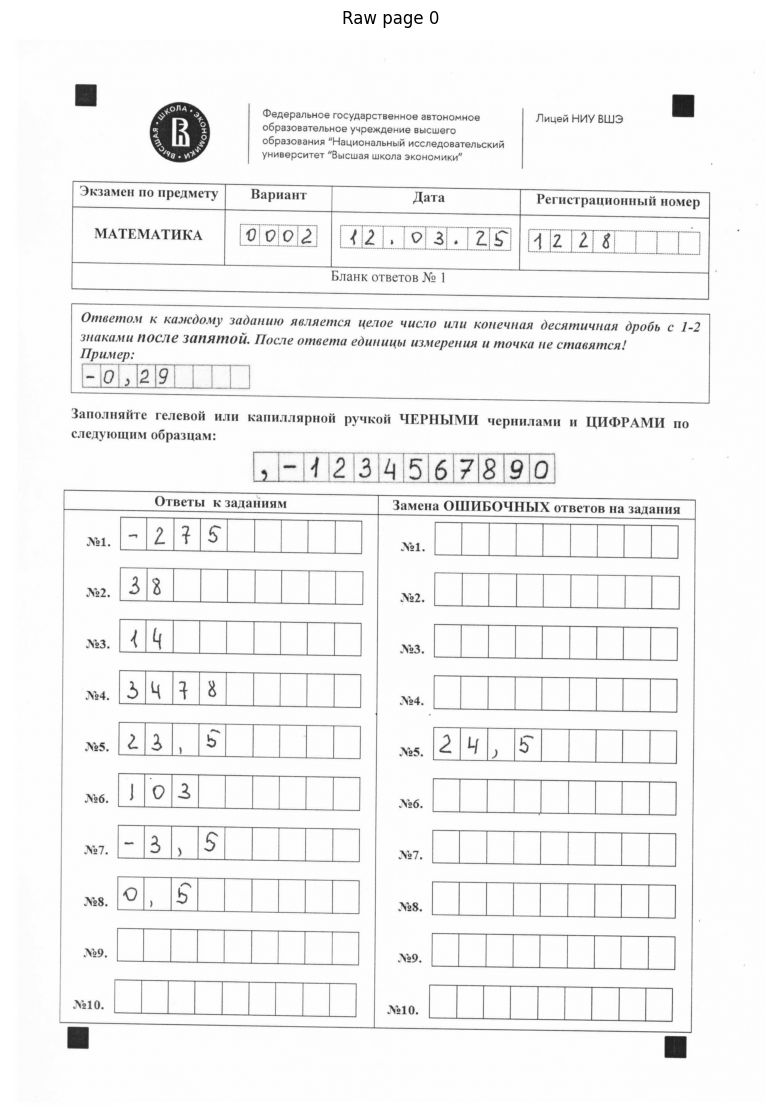

In [3]:
from exam_grader.processing.image_processing import get_page_image_from_pdf, get_pdf_page_count

with open(PDF_PATH, "rb") as f:
    pdf_bytes = f.read()

num_pages = get_pdf_page_count(pdf_bytes)
print(f"PDF has {num_pages} page(s)")

page_image = get_page_image_from_pdf(pdf_bytes, PAGE_INDEX)
print(f"Page image shape: {page_image.shape}, dtype: {page_image.dtype}")

plt.figure(figsize=(10, 14))
plt.imshow(page_image, cmap="gray")
plt.title(f"Raw page {PAGE_INDEX}")
plt.axis("off")
plt.show()

## 2. Create Form and load metadata

In [4]:
from exam_grader.models.form import Form

form = Form(version_input=VERSION)
form.load_meta_from_json(str(CELL_COORDS_PATH))
form.load_image(page_image)
form.load_template(str(TEMPLATE_PATH))

print(f"Rows loaded: {list(form.rows.keys())}")
print(f"Cells in answer1: {len(form.rows['answer1'].cells)}")
print(f"Sample cell coords (answer1, cell0): "
      f"x={form.rows['answer1'].cells[0].x}, "
      f"y={form.rows['answer1'].cells[0].y}, "
      f"w={form.rows['answer1'].cells[0].w}, "
      f"h={form.rows['answer1'].cells[0].h}")

Rows loaded: ['date', 'user_id', 'version', 'answer1', 'answer2', 'answer3', 'answer4', 'answer5', 'answer6', 'answer7', 'answer8', 'answer9', 'answer10', 'correction1', 'correction2', 'correction3', 'correction4', 'correction5', 'correction6', 'correction7', 'correction8', 'correction9', 'correction10']
Cells in answer1: 9
Sample cell coords (answer1, cell0): x=510, y=2300, w=126, h=154


## 3. Align image to template

Aligned image shape: (5052, 3570)


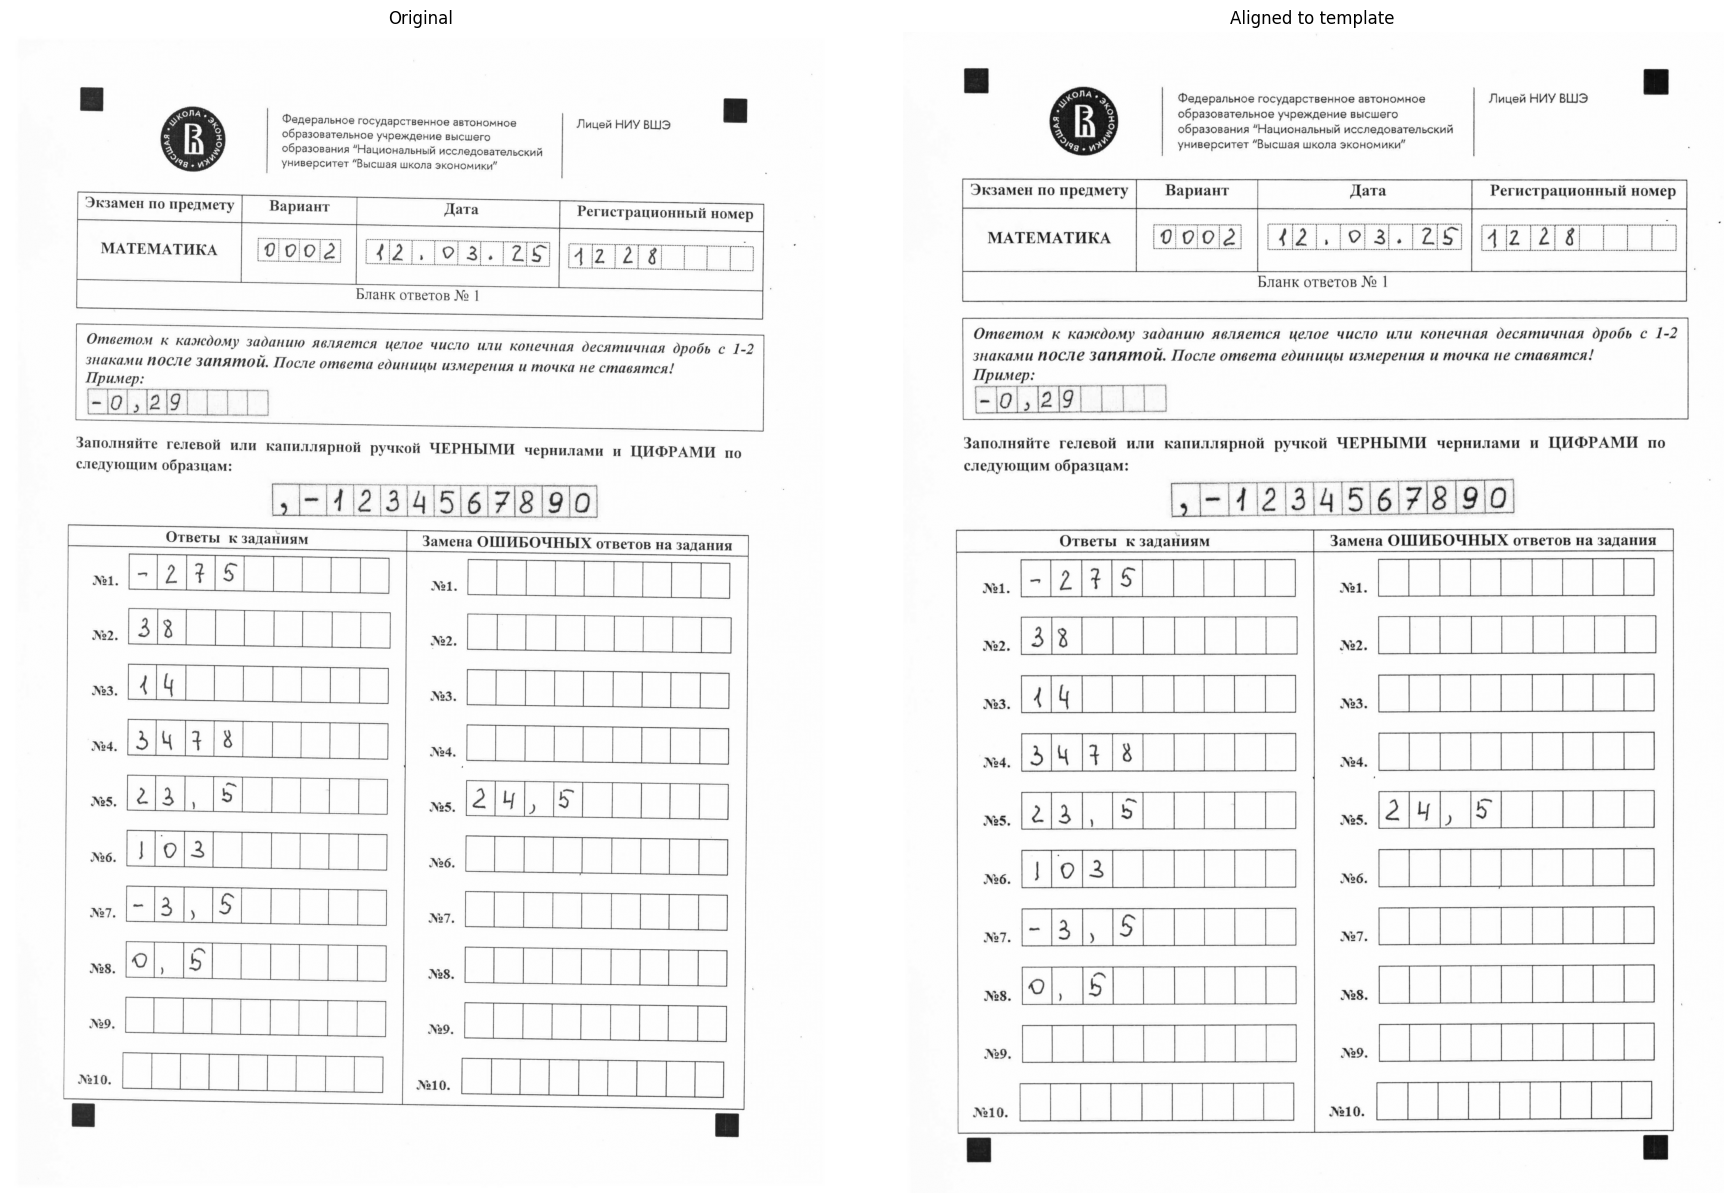

In [5]:
form.align_form(scale_factor=1.5)

print(f"Aligned image shape: {form.image.shape}")

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
axes[0].imshow(page_image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(form.image, cmap="gray")
axes[1].set_title("Aligned to template")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### 3.1 Visualize cell positions on aligned image

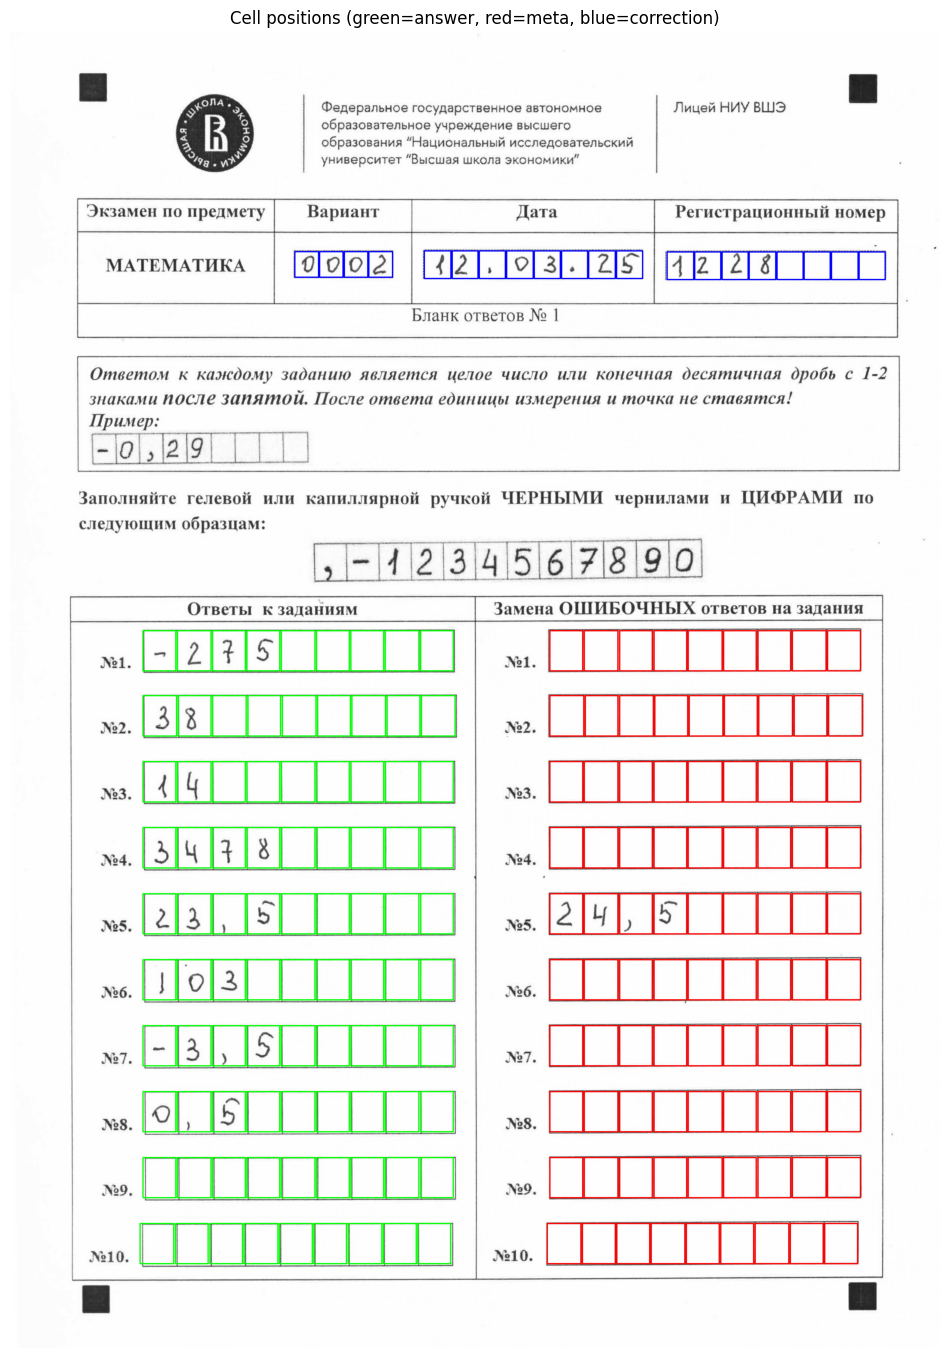

In [6]:
vis = cv2.cvtColor(form.image.copy(), cv2.COLOR_GRAY2BGR)

for row_name, row in form.rows.items():
    color = (0, 255, 0) if "answer" in row_name else (255, 0, 0)
    if "correction" in row_name:
        color = (0, 0, 255)
    for cell in row.cells:
        if cell.x is not None:
            cv2.rectangle(vis, (cell.x, cell.y), (cell.x + cell.w, cell.y + cell.h), color, 3)

plt.figure(figsize=(12, 18))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Cell positions (green=answer, red=meta, blue=correction)")
plt.axis("off")
plt.show()

## 4. Style image (borders, inversion, symbol centering)

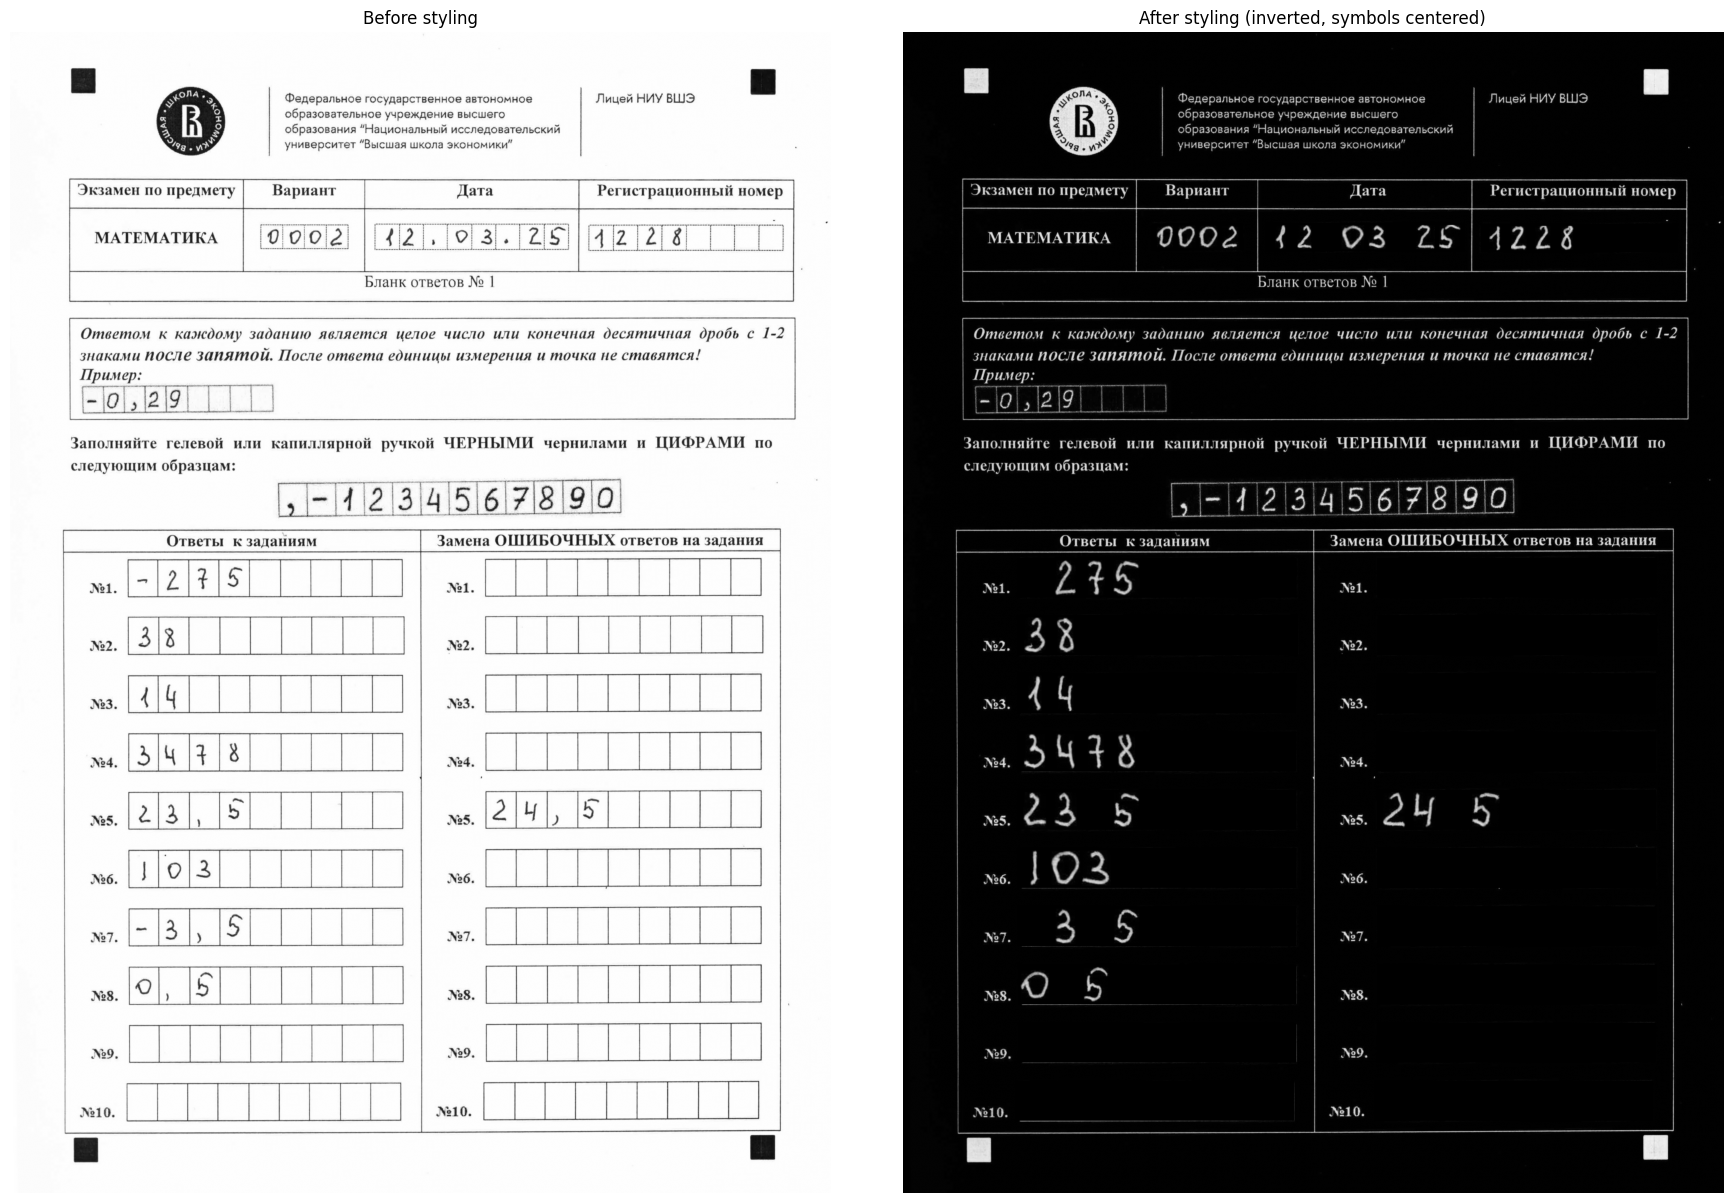

In [7]:
image_before_styling = form.image.copy()
form.style_image()

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
axes[0].imshow(image_before_styling, cmap="gray")
axes[0].set_title("Before styling")
axes[0].axis("off")
axes[1].imshow(form.image, cmap="gray")
axes[1].set_title("After styling (inverted, symbols centered)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### 4.1 Inspect individual cells after styling

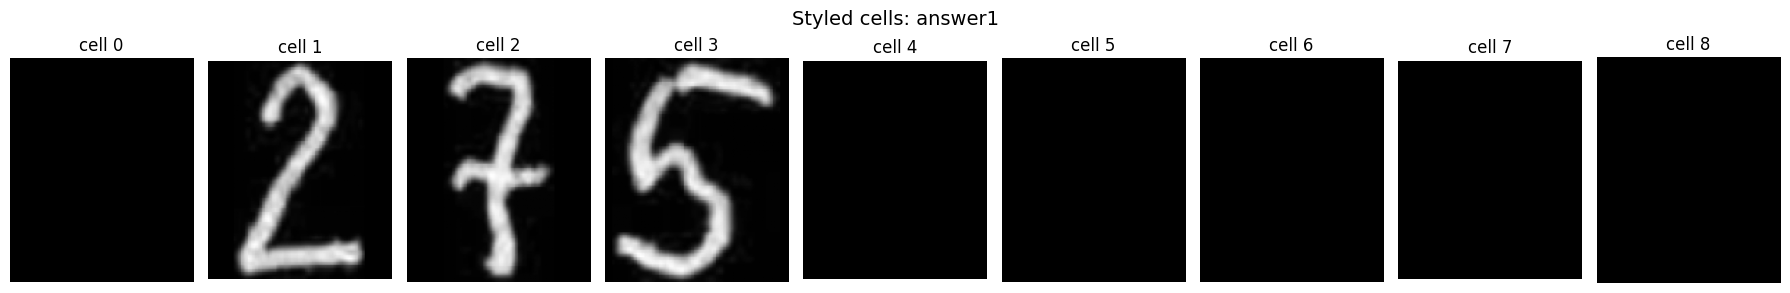

In [8]:
ROW_TO_INSPECT = "answer1"  # change this to inspect different rows

row = form.rows[ROW_TO_INSPECT]
n_cells = len(row.cells)
fig, axes = plt.subplots(1, n_cells, figsize=(2 * n_cells, 3))

for i, cell in enumerate(row.cells):
    x, y, w, h = cell.x, cell.y, cell.w, cell.h
    cell_img = form.image[y:y+h, x:x+w]
    axes[i].imshow(cell_img, cmap="gray")
    axes[i].set_title(f"cell {i}")
    axes[i].axis("off")

plt.suptitle(f"Styled cells: {ROW_TO_INSPECT}", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Load correct answers

In [9]:
answers_df = pd.read_excel(ANSWERS_PATH)
display(answers_df)

form.load_correct_answers(answers_df)

print("\nCorrect answers loaded per row:")
for i in range(1, NUM_QUESTIONS + 1):
    row = form.rows[f"answer{i}"]
    correct_vals = [c.correct_value for c in row.cells]
    print(f"  answer{i}: {correct_vals}")

,Вариант,1,2,3,4,5,6,7,8,9,10
0,1,-98,240,0,150,"16,9",280,-8,-54,"10,8","4,5"
1,2,-275,"37,5",14,3478,"24,5",102,-3,"-0,5","17,5","-0,75"
2,3,-2,5,0,88642,"8,5",-35,-16,-9,12,"0,625"
3,4,-2,30,5,92,60,5,-4,-2,30,"4,25"
4,5,"-0,9",60,2,33,12,17,9,"0,25","86,4","-0,25"
5,6,2,20,"1,08",16,20,13500,6,4,7,-50



Correct answers loaded per row:
  answer1: ['-', '9', '8', None, None, None, None, None, None]
  answer2: ['2', '4', '0', None, None, None, None, None, None]
  answer3: ['0', None, None, None, None, None, None, None, None]
  answer4: ['1', '5', '0', None, None, None, None, None, None]
  answer5: ['1', '6', ',', '9', None, None, None, None, None]
  answer6: ['2', '8', '0', None, None, None, None, None, None]
  answer7: ['-', '8', None, None, None, None, None, None, None]
  answer8: ['-', '5', '4', None, None, None, None, None, None]
  answer9: ['1', '0', ',', '8', None, None, None, None, None]
  answer10: ['4', ',', '5', None, None, None, None, None, None]


## 6. Run digit recognition (CLIP)

In [10]:
%%time
form.get_user_answers_pipeline()
print("Recognition complete.")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 990.51it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Recognition complete.
CPU times: total: 3min 15s
Wall time: 28.7 s


### 6.1 Inspect recognized values

In [11]:
print("Recognized answers:")
print(f"  Date:    {''.join(v or '_' for v in form.rows['date'].user_answers)}")
print(f"  User ID: {''.join(v or '_' for v in form.rows['user_id'].user_answers)}")
print(f"  Version: {''.join(v or '_' for v in form.rows['version'].user_answers)}")
print()

results = []
for i in range(1, NUM_QUESTIONS + 1):
    a_row = form.rows[f"answer{i}"]
    c_row = form.rows[f"correction{i}"]
    answer = "".join(v or "_" for v in a_row.user_answers)
    correction = "".join(v or "_" for v in c_row.user_answers)
    correct = a_row.correct_answers[0] if a_row.correct_answers and isinstance(a_row.correct_answers[0], str) else "?"
    results.append({
        "Q": i,
        "Recognized": answer,
        "Correction": correction,
        "Correct": correct,
    })

results_df = pd.DataFrame(results)
display(results_df)

Recognized answers:
  Date:    12_03_25
  User ID: 1228____
  Version: 0002



,Q,Recognized,Correction,Correct
0,1,-275_____,_________,-
1,2,38_______,_________,2
2,3,14_______,_________,0
3,4,3478_____,_________,1
4,5,"23,5_____","24,5_____",1
5,6,103______,_________,2
6,7,"-3,5_____",_________,-
7,8,"0,5______",_________,-
8,9,_________,_________,1
9,10,_________,_________,4


### 6.2 Visual comparison: cell image vs recognized digit

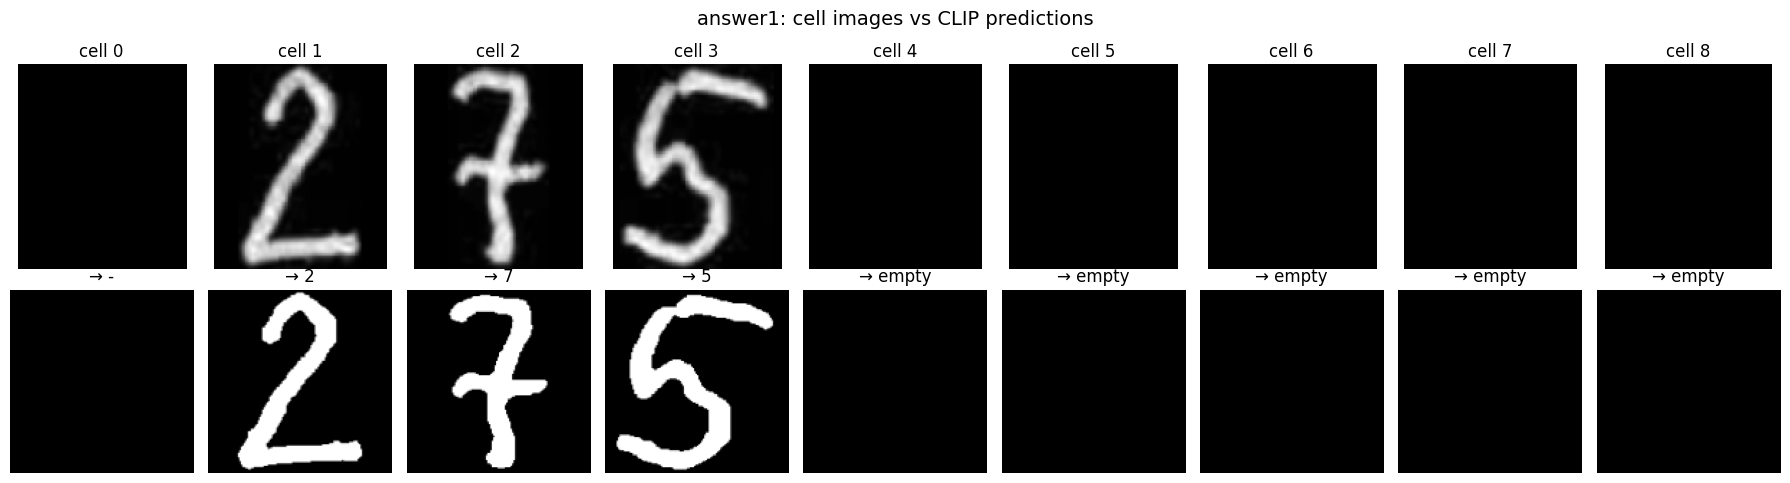

In [12]:
ROW_TO_INSPECT = "answer1"  # change to inspect other rows

row = form.rows[ROW_TO_INSPECT]
n_cells = len(row.cells)
fig, axes = plt.subplots(2, n_cells, figsize=(2 * n_cells, 5))

for i, cell in enumerate(row.cells):
    x, y, w, h = cell.x, cell.y, cell.w, cell.h
    cell_img = form.image[y:y+h, x:x+w]
    axes[0, i].imshow(cell_img, cmap="gray")
    axes[0, i].set_title(f"cell {i}")
    axes[0, i].axis("off")

    if cell.cell_pred_input is not None:
        axes[1, i].imshow(cell.cell_pred_input)
    axes[1, i].set_title(f"→ {cell.user_value or 'empty'}")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Styled cell", fontsize=12)
axes[1, 0].set_ylabel("CLIP input", fontsize=12)
plt.suptitle(f"{ROW_TO_INSPECT}: cell images vs CLIP predictions", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Generate row preview images

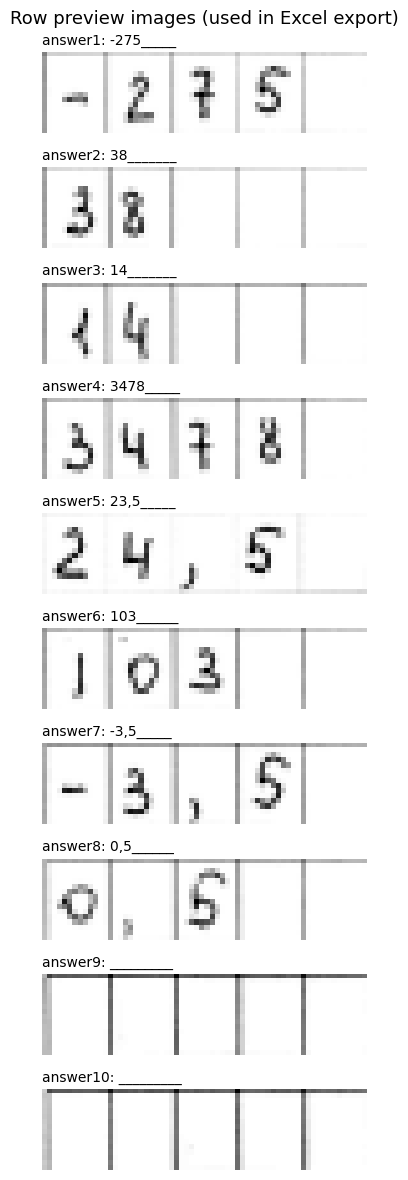

In [13]:
form.set_row_images()

fig, axes = plt.subplots(NUM_QUESTIONS, 1, figsize=(6, NUM_QUESTIONS * 1.2))

for i in range(NUM_QUESTIONS):
    row = form.rows[f"answer{i + 1}"]
    if row.row_image is not None:
        axes[i].imshow(row.row_image, cmap="gray")
    answer_str = "".join(v or "_" for v in row.user_answers)
    axes[i].set_title(f"answer{i+1}: {answer_str}", loc="left", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Row preview images (used in Excel export)", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Full pipeline via FormRecognition (end-to-end)

In [14]:
from exam_grader.recognition.pipeline import FormRecognition

page_img = get_page_image_from_pdf(pdf_bytes, PAGE_INDEX)
answers_df = pd.read_excel(ANSWERS_PATH)

recognition = FormRecognition(
    image=page_img,
    template_path=str(TEMPLATE_PATH),
    json_path=str(CELL_COORDS_PATH),
    answers=answers_df,
    version=VERSION,
)

%time result_form = recognition.run_pipeline()
print("Pipeline complete.")

CPU times: total: 3min 38s
Wall time: 28.7 s
Pipeline complete.


## 9. Grading

In [15]:
from exam_grader.export.excel import prepare_form_dict, transform_to_dataframe
from exam_grader.grading.grader import (
    get_correct_answers, postprocess_raw_output, check_answers, final_styling,
)

cur_dict = prepare_form_dict(result_form)
df = transform_to_dataframe(cur_dict)
display(df)

with open(ANSWERS_PATH, "rb") as f:
    answers_bytes = f.read()

correct = get_correct_answers(answers_bytes)
df_processed = postprocess_raw_output(df, correct, VERSION)
df_checked = check_answers(df_processed)
df_styled = final_styling(df_checked)

print("\nFinal graded results:")
display(df_styled)

,Дата,Код участника,Вариант,Задание 1,Задание 2,Задание 3,Задание 4,Задание 5,Задание 6,Задание 7,...,Замена 1,Замена 2,Замена 3,Замена 4,Замена 5,Замена 6,Замена 7,Замена 8,Замена 9,Замена 10
0,120325,1228,0002,-275,38,14,3478,"23,5",103,"-3,5",...,,,,,"24,5",,,,,



Final graded results:


c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\notebooks\..\exam_grader\grading\grader.py:13: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  df = pd.read_excel(correct_answers_path)


,Дата,Код участника,Вариант,Задание 1,Задание 2,Задание 3,Задание 4,Задание 5,Задание 6,Задание 7,...,Начисленные баллы 2,Начисленные баллы 3,Начисленные баллы 4,Начисленные баллы 5,Начисленные баллы 6,Начисленные баллы 7,Начисленные баллы 8,Начисленные баллы 9,Начисленные баллы 10,Начисленные баллы сумма
0,120325,1228,1,-275.0,38.0,14.0,3478.0,24.5,103.0,-3.5,...,0,0,0,0,0,0,0,0,0,0


## 10. Export to Excel

In [18]:
from exam_grader.export.excel import add_image_columns, save_to_excel

df_with_images = add_image_columns(df_styled)
form_dict = {0: result_form}
excel_data = save_to_excel(df_with_images, form_dict)

output_path = "../test_output.xlsx"
with open(output_path, "wb") as f:
    f.write(excel_data.getvalue())

print(f"Excel saved to {output_path} ({len(excel_data.getvalue())} bytes)")

Excel saved to ../test_output.xlsx (16404 bytes)


## 11. Multi-page PDF test

In [20]:
# Uncomment and run to test multi-page processing:

df_global = pd.DataFrame()
all_forms = {}

for page_idx in range(num_pages):
    print(f"Processing page {page_idx + 1}/{num_pages}...")
    img = get_page_image_from_pdf(pdf_bytes, page_idx)
    rec = FormRecognition(
        image=img,
        template_path=str(TEMPLATE_PATH),
        json_path=str(CELL_COORDS_PATH),
        answers=answers_df,
        version=VERSION,
    )
    f = rec.run_pipeline()
    d = prepare_form_dict(f)
    df_cur = transform_to_dataframe(d)
    df_global = pd.concat([df_global, df_cur]).reset_index(drop=True)
    all_forms[page_idx] = f

correct = get_correct_answers(answers_bytes)
df_proc = postprocess_raw_output(df_global, correct, VERSION)
df_chk = check_answers(df_proc)
df_fin = final_styling(df_chk)
df_fin = add_image_columns(df_fin)
excel = save_to_excel(df_fin, all_forms)

with open("../test_multi_page.xlsx", "wb") as f:
    f.write(excel.getvalue())
print("Multi-page export done.")

Processing page 1/19...
Processing page 2/19...
Processing page 3/19...
Processing page 4/19...
Processing page 5/19...
Processing page 6/19...
Processing page 7/19...
Processing page 8/19...
Processing page 9/19...
Processing page 10/19...
Processing page 11/19...
Processing page 12/19...
Processing page 13/19...
Processing page 14/19...
Processing page 15/19...
Processing page 16/19...
Processing page 17/19...
Processing page 18/19...
Processing page 19/19...


c:\Users\zamko\Documents\vlzm\streamlit-exam-form-app\notebooks\..\exam_grader\grading\grader.py:13: FutureWarning: Passing bytes to 'read_excel' is deprecated and will be removed in a future version. To read from a byte string, wrap it in a `BytesIO` object.
  df = pd.read_excel(correct_answers_path)


Multi-page export done.
